In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
from pyomo.opt import SolverFactory
from pyomo.core import Var
import pyomo.environ as en
import pickle

In [11]:
# load the data
with open('ID_heat_elec.pkl', 'rb') as f:
    ID_heat_elec = pickle.load(f)

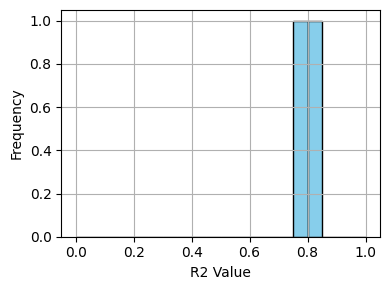

In [12]:
R2_values = [ID_heat_elec[key]['COP model']['R2'] for key in ID_heat_elec.keys()]

# Define bins within [0, 1] — for example, 20 equally spaced bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot
plt.figure(figsize=(4, 3))
plt.hist(R2_values, bins=bins, edgecolor='black', color='skyblue')
plt.xlabel('R2 Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
avg_prices_df = pd.read_parquet("average_agile_tariff_UK.parquet")
price = avg_prices_df['avg_price'].values

In [28]:
print(f"The average electricity price is {np.mean(price):.4} £/kWh")

The average electricity price is 25.61 £/kWh


### PLAN

* We have a timeseries for the heat out for electric and hot water, as well as the electric for both heat and hot water
* We also have COP for both SH and DHW
* Set up an optimisation to minimise the total running cost $\sum_t E_t^{tot} \pi_t$, where $E_t^{tot} = E_t^{SH} + E_t^{DHW}$
* $Q^{SH}$ and $Q^{DHW}$ are the constraints, so must always be met
* Heat from the TES can reduce either, but it will reduce $E_t^{SH}$ by $\Delta Q_t^{TES}/COP_t^{SH}$
* it will reduce $E_t^{DHW}$ by $\Delta Q_t^{TES}/COP_t^{DHW}$
* Where $\Delta Q_t^{TES}$ is the output from the TES
* Constraints that $E_t^{SH}/geq0$ and $E_t^{DHW}/geq0$ 

<br>

* We can also run an optimisation to minimise the peak value of $E_t^{tot}$


In [ ]:
keys = [key for key in ID_heat_elec.keys()]
EoH_ID = keys[0]

In [16]:
   
t = time.time()

print('EOH ID = '+EoH_ID)
Q_SH = ID_heat_elec[EoH_ID]['HH_data']['Heat_out_space_heat'].values
Q_DHW = ID_heat_elec[EoH_ID]['HH_data']['Heat_out_hot_water'].values
# at the moment, we do not use the electric data, just heat and COP
# SH_elec = ID_heat_elec[EoH_ID]['HH_data']['Electric_space_heat'].values
# DHW_elec = ID_heat_elec[EoH_ID]['HH_data']['Electric_hot_water'].values
COP_SH = ID_heat_elec[EoH_ID]['HH_data']['COP_space_heat'].values
COP_DHW = ID_heat_elec[EoH_ID]['HH_data']['COP_hot_water'].values

# use simulated electric as it is less crazy (possibly due to missing vals in data)
E_SH = Q_SH/COP_SH
E_DHW = Q_DHW/COP_SH

thermal_store_caps = [10,30]
thermal_powers = [T/4 for T in thermal_store_caps]
charge_powers = [2.5 for T in thermal_store_caps]

######### Optimisation to minimise running costs
totalCost = np.zeros((len(thermal_store_caps)+1))
totalElecUsage = np.zeros((len(thermal_store_caps)+1))
maxHeatOut = np.zeros((len(thermal_store_caps)+1))

for opt_count in range(len(thermal_store_caps)):

    # define the parameters for the thermal store
    TES1 = dict()
    TES1['capacity'] = thermal_store_caps[opt_count] #kWh
    TES1['chargeLimit'] = charge_powers[opt_count] #kWh per hour
    TES1['dischargeLimit'] = thermal_powers[opt_count] #kWh per hour
    TES1['SOC'] = np.zeros((len(heat)))
    TES1['deltaSOC'] = np.zeros((len(heat)))
    TES1['etaChg'] = 1. #both charging and discharging have 100% efficiency
    TES1['etaDis'] = 1. #round trip efficiency 100%
    TES1['initialCharge'] = 0

    Q_DictSH = dict(enumerate(Q_SH))
    E_DictSH = dict(enumerate(E_SH))
    Q_DictDHW = dict(enumerate(Q_DHW))
    E_DictSDHW = dict(enumerate(E_DHW))
    COP_DictSH = dict(enumerate(COP_SH))
    COP_DictDHW = dict(enumerate(COP_DHW))

    # now set up the pyomo model
    m = en.ConcreteModel()
    # we use rangeset to make a sequence of integers
    # time is what we will use as the model index
    m.Time = en.RangeSet(0, len(heat)-1)

    #####################################################################################

    # variables (all indexed by Time)
    m.SOC = en.Var(m.Time, bounds=(0,TES1['capacity']), initialize=0) #0
    m.posDeltaSOC = en.Var(m.Time, bounds=(0, TES1['chargeLimit']), initialize=0) #1
    # posDeltaSOC is energy added to TES1
    m.negDeltaSOC = en.Var(m.Time, bounds=(-TES1['dischargeLimit'], 0), initialize=0) #2
    # negDeltaSOC is energy removed from TES1
    m.posEIn = en.Var(m.Time, initialize=0) #3
    # posEIn is energy required for posDeltaSOC
    m.negEOut = en.Var(m.Time, initialize=0) #4
    # negEOut is result of negDeltaSOC

    m.netElec = en.Var(m.Time, initialize=0) #5
    # netElec will be the decision variable
    m.netHeat = en.Var(m.Time, initialize=0) #6
    # this is just for tracking where heat comes from & for constraint (Q>=0)

    # Boolean variables (again indexed by Time)
    m.Bool_char=en.Var(m.Time,within=en.Boolean) #7
    m.Bool_dis=en.Var(m.Time,within=en.Boolean,initialize=0) #8

    # parameters (indexed by time)
    m.E_SH = en.Param(m.Time, initialize=E_DictSH)
    m.Q_SH = en.Param(m.Time, initialize=Q_DictSH)
    m.E_DHW = en.Param(m.Time, initialize=E_DictDHW)
    m.Q_DHW = en.Param(m.Time, initialize=Q_DictDHW)

    # set an initial parameter for the COP
    m.COP_SH = en.Param(m.Time, initialize=COP_DictSH)
    m.COP_DWH = en.Param(m.Time, initialize=COP_DictDHW)

    # single value parameters
    m.etaChg = en.Param(initialize = TES1['etaChg'])
    m.etaDisChg = en.Param(initialize = TES1['etaDis'])
    m.chgLimit = en.Param(initialize = TES1['chargeLimit'])
    m.disLimit = en.Param(initialize = -TES1['dischargeLimit'])

    #####################################################################################
    ##### if we are minimising the peak
    # # cost of the peak demand
    # m.cost_peak = en.Param(initialize=1)
    # m.cost_sum = en.Param(initialize=1E-4)

    # # we need a variable to store the max value of m.netLoad
    # m.maxElec = en.Var(domain=en.Reals) #9
    # def Peak_Rule(m, i):
    #     return m.maxElec >= m.netElec[i]
    # m.bound_peak = en.Constraint(m.Time,rule=Peak_Rule)

    # # objective function
    # def Obj_fn(m):
    #     return m.cost_peak*m.maxElec + m.cost_sum*sum(m.netElec[i] for i in m.Time)
    # m.total_cost = en.Objective(rule=Obj_fn,sense=en.minimize)

    #####################################################################################
    
    # objective function
    def Obj_fn(m):
        return sum(m.netElec[i]*m.price[i] for i in m.Time)
    m.total_cost = en.Objective(rule=Obj_fn,sense=en.minimize)

    #####################################################################################

    def SOC_rule(m,i):
        if i==0:
            return (m.SOC[i] == m.posDeltaSOC[i]+m.negDeltaSOC[i])
        else:
            return (m.SOC[i] == m.SOC[i-1]+m.posDeltaSOC[i]+m.negDeltaSOC[i])   
    # then we specify that this constraint is indexed by time
    m.store_SOC = en.Constraint(m.Time,rule=SOC_rule)

    #####################################################################################

    bigM=500000
    # boolean constraints
    def Bool_char_rule_1(m,i):
        return((m.posDeltaSOC[i])>=-bigM*(m.Bool_char[i]))
    m.Batt_ch1=en.Constraint(m.Time,rule=Bool_char_rule_1)
    # if battery is charging, charging must be greater than -large
    # if not, charging geq zero
    def Bool_char_rule_2(m,i):
        return((m.posDeltaSOC[i])<=0+bigM*(1-m.Bool_dis[i]))
    m.Batt_ch2=en.Constraint(m.Time,rule=Bool_char_rule_2)
    # if batt discharging, charging must be leq zero
    # if not, charging leq +large
    def Bool_char_rule_3(m,i):
        return((m.negDeltaSOC[i])<=bigM*(m.Bool_dis[i]))
    m.Batt_cd3=en.Constraint(m.Time,rule=Bool_char_rule_3)
    # if batt discharge, discharge leq POSITIVE large
    # if not, discharge leq 0
    def Bool_char_rule_4(m,i):
        return((m.negDeltaSOC[i])>=0-bigM*(1-m.Bool_char[i]))
    m.Batt_cd4=en.Constraint(m.Time,rule=Bool_char_rule_4)
    # if batt charge, discharge geq zero
    # if not, discharge geq -large
    def Batt_char_dis(m,i):
        return (m.Bool_char[i]+m.Bool_dis[i],1)
    m.Batt_char_dis=en.Constraint(m.Time,rule=Batt_char_dis)

    #####################################################################################

    #ensure charging efficiency is divided
    def pos_E_in_rule(m,i):
        return m.posEIn[i] == m.posDeltaSOC[i]/m.etaChg
    m.posEIn_cons = en.Constraint(m.Time, rule=pos_E_in_rule)
    # ensure discharging eff multiplied
    def neg_E_out_rule(m,i):
        return m.negEOut[i] == m.negDeltaSOC[i]*m.etaDisChg
    m.negEOut_cons = en.Constraint(m.Time, rule=neg_E_out_rule)

    #####################################################################################

    # ensure charging rate obeyed
    def E_charging_rate_rule(m,i):
        return m.posEIn[i]<=m.chgLimit
    m.chgLimit_cons = en.Constraint(m.Time, rule=E_charging_rate_rule)
    # ensure discharging rate obeyed
    def E_discharging_rate_rule(m,i):
        return m.negEOut[i]>=m.disLimit
    m.disLimit_cons = en.Constraint(m.Time, rule=E_discharging_rate_rule)
    #m.del_component(m.posEIn_cons), m.del_component(m.negEOut_cons)

    #####################################################################################

    # calculate the net electric demand
    def E_elec_rule(m,i):
        # return m.netElec[i] == m.elec[i]+m.posEIn[i]/m.COP[i]+m.negEOut[i]/m.COP[i] # heat pump charged
        return m.netElec[i] == m.elec[i]+m.posEIn[i]+m.negEOut[i]/m.COP[i] # resistance charged
    m.E_net_cons = en.Constraint(m.Time,rule=E_elec_rule)
    def E_heat_rule(m,i):
        return m.netHeat[i] == m.heat[i] + m.negEOut[i]
    m.E_heat_net_cons = en.Constraint(m.Time,rule=E_heat_rule)

    #####################################################################################

    # don't allow storage to discharge if no heat required
    def E_neg_heat_rule(m,i):
        return m.netHeat[i] >= 0
    m.E_neg_heat_cons = en.Constraint(m.Time,rule=E_neg_heat_rule)

    # add a constraint that is dont allow for electric to reduce below zero
    def E_neg_elec_rule(m,i):
        return m.netElec[i] >= 0
    m.E_net_neg_elec_cons = en.Constraint(m.Time,rule=E_neg_elec_rule)

    #####################################################################################

    # set the path to the solver
    opt = SolverFactory("cplex", executable="/Applications/CPLEX_Studio2211/cplex/bin/arm64_osx/cplex")

    #####################################################################################

    results = opt.solve(m)

    #####################################################################################

    j = 0
    for v in m.component_objects(Var, active=True):
        # print(j, v.getname())
        j+=1

    #####################################################################################

    # now let's read in the value for each of the variables 
    outputVars = np.zeros((9,len(heat)))
    j = 0
    for v in m.component_objects(Var, active=True):
        # print(v.getname())
        #print varobject.get_values()
        varobject = getattr(m, str(v))
        for index in varobject:
            outputVars[j,index] = varobject[index].value
        j+=1
        if j>=9:
            break

    maxElecDemand[opt_count+1] = m.maxElec.value
    totalElecUsage[opt_count+1] = np.sum(outputVars[5,:])
    maxHeatOut[opt_count+1] = max(v.value for v in m.netHeat.values())

    if opt_count==0:
        maxElecDemand[opt_count] = elec_sim.max()
        totalElecUsage[opt_count] = elec_sim.sum()
        maxHeatOut[opt_count] = heat.max()

    # if opt_count == 5:
    #     print(thermal_store_caps[opt_count])
    #     break

ID_heat_elec[EoH_ID]['max electric demand'] = maxElecDemand
ID_heat_elec[EoH_ID]['total electric demand'] = totalElecUsage
ID_heat_elec[EoH_ID]['max heat output'] = maxHeatOut

elapsed = time.time() - t
print('Time elapsed:', elapsed)

EOH ID = EOH0234


KeyError: 'hourly_data'